# 01 — One trajectory is not enough

**The point of this notebook is negative.** It shows how little a single observed
agent reveals about the mechanism it belongs to, which is the premise the whole
project rests on: if one trajectory sufficed, `Q3` and `Q4` would not exist.

Read `PROJECT.md` first. Everything below imports from `collectivediff` — this
notebook contains no simulation or estimation logic, per the conventions in
section 2.

In [1]:
import numpy as np

from collectivediff.config import (
    BrownianConfig, CTRWConfig, DDMConfig, FBMConfig,
    LevyWalkConfig, SBMConfig,
)
from collectivediff.generators import generate
from collectivediff.studies import RESULTS_ROOT, single_trajectory_report
from collectivediff.viz import (
    AnimationStyle, STYLES, animate_trajectories, plot_single_trajectory_panel,
    plot_trajectories, save_animation,
)

# display_animation() would embed every frame as a base64 PNG in the notebook
# file itself (PHASE1_REVIEW.md item 5: 86 per cent of this notebook was that
# encoding). Animations are instead written to results/media/ and shown with a
# plain <video> tag, which references the file rather than inlining it.
import dataclasses
from IPython.display import HTML
MEDIA = RESULTS_ROOT / "media"

def show_video(anim, name):
    # A relative path, since nbconvert/Jupyter run with cwd = the notebook's
    # own directory, and that is what a live Jupyter server can actually serve.
    path = save_animation(anim, MEDIA / name, fps=20)
    import os
    rel = os.path.relpath(path, start=".")
    tag = '<video controls loop muted autoplay width="420" src="' + rel + '"></video>'
    return HTML(tag)

SINGLE = dataclasses.replace(STYLES["single"], max_frames=90)
FEW = dataclasses.replace(STYLES["few"], max_frames=90)

## Five mechanisms, spanning sub-, normal and superdiffusion

Configs are frozen dataclasses and every figure below is reproducible from
`(config, seed)` alone.

In [2]:
MECHANISMS = {
    "brownian": BrownianConfig(seed=0),
    "fbm H=0.3": FBMConfig(hurst=0.3, seed=0),
    "sbm a=0.6": SBMConfig(alpha=0.6, seed=0),
    "ctrw a=0.5": CTRWConfig(alpha_wait=0.5, seed=0),
    "levy_walk g=1.5": LevyWalkConfig(gamma=1.5, seed=0),
}

for label, cfg in MECHANISMS.items():
    print(f"{label:<16} ensemble alpha = {cfg.alpha_analytic:.2f}")

brownian         ensemble alpha = 1.00
fbm H=0.3        ensemble alpha = 0.60
sbm a=0.6        ensemble alpha = 0.60
ctrw a=0.5       ensemble alpha = 0.50
levy_walk g=1.5  ensemble alpha = 1.50


## What one trajectory says about itself

For each mechanism: one trajectory of 4096 steps, and the exponent obtained by
fitting *that trajectory's own* time-averaged MSD — the only observable an
experimenter watching one agent actually has.

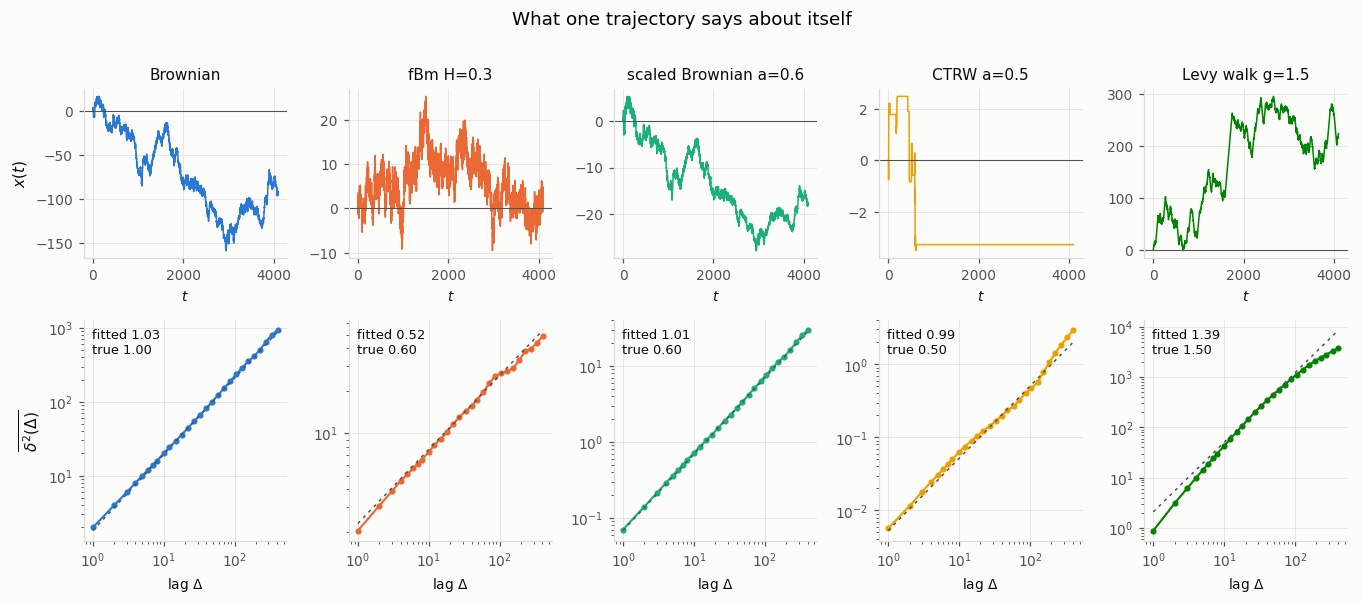

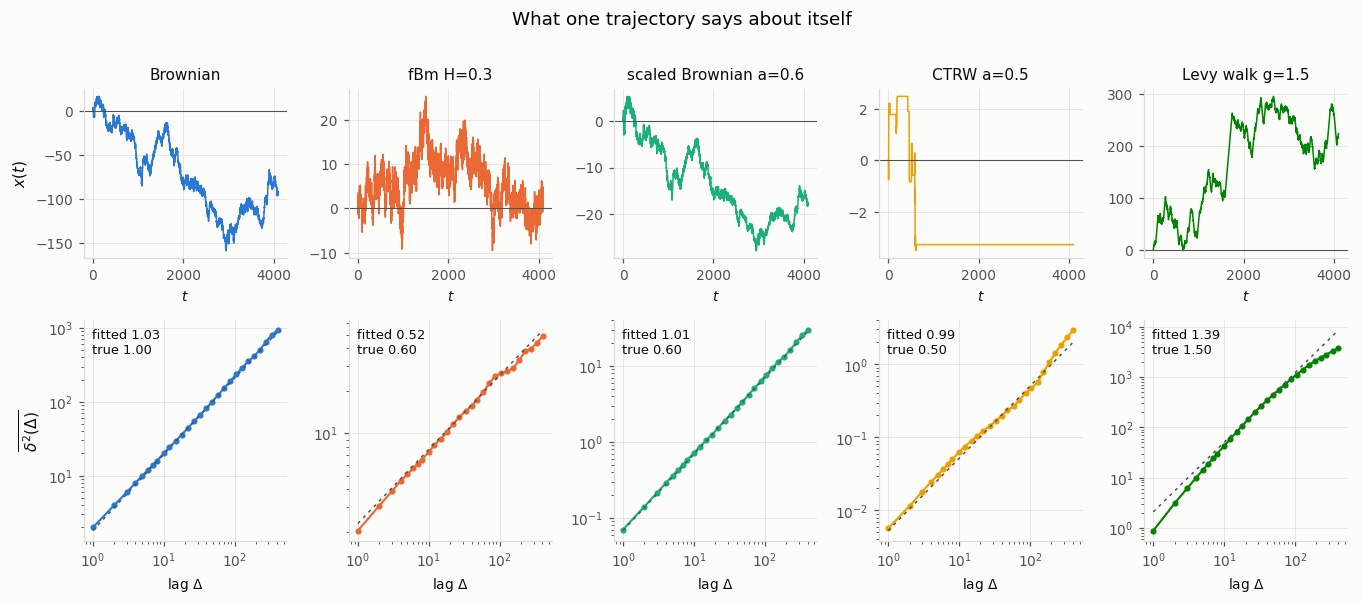

In [3]:
report = single_trajectory_report(MECHANISMS, n_steps=4096)
fig = plot_single_trajectory_panel(report)
fig

### Read the bottom row, not the top

The traces are distinguishable by eye. The *estimates* are not:

| mechanism | true ensemble α | single-trajectory α |
|---|---|---|
| Brownian | 1.00 | ≈ 1.03 |
| fBm H=0.3 | 0.60 | ≈ 0.52 |
| scaled Brownian α=0.6 | **0.60** | **≈ 1.01** |
| CTRW a=0.5 | **0.50** | **≈ 0.99** |
| Lévy walk g=1.5 | 1.50 | ≈ 1.39 |

Two of the five report normal diffusion while being strongly subdiffusive.
This is not noise and it does not improve with a longer trajectory:

- the **CTRW** is weakly non-ergodic. Its TA-MSD grows *linearly in the lag*
  whatever `a` is, with an amplitude that stays random however long you watch
  (He et al., PRL 101, 058101). No amount of memory recovers `a`.
- **scaled Brownian motion** is non-stationary. Its TA-MSD is also linear in
  the lag, ageing as a power of the measurement time instead.

Only fBm — the one ergodic anomalous mechanism here — lets one trajectory
approach the ensemble answer.

## The same conclusion, animated

Two-dimensional generators exist for visualisation (`PROJECT.md` section 2);
all statistics above ran in 1-D.

In [4]:
levy = LevyWalkConfig(n_particles=1, n_steps=900, gamma=1.5, tau0=5.0, n_dim=2, seed=0)
walk = generate(levy, np.random.default_rng(levy.seed))
anim = animate_trajectories(walk, SINGLE, mechanism=levy,
                            title="Levy walk: ballistic runs between turns")
show_video(anim, "levy_walk_single.mp4")

In [5]:
ctrw = CTRWConfig(n_particles=1, n_steps=900, alpha_wait=0.5, n_dim=2, seed=0)
walk = generate(ctrw, np.random.default_rng(ctrw.seed))
anim = animate_trajectories(walk, SINGLE, mechanism=ctrw,
                            title="CTRW: long pauses, sudden jumps")
show_video(anim, "ctrw_single.mp4")

Watch the clock rather than the path. The Lévy walker never stops; the CTRW
walker spends most of the run motionless and covers its ground in bursts. Both
produce a trail; only one of them is moving most of the time.

In [6]:
few = CTRWConfig(n_particles=8, n_steps=900, alpha_wait=0.5, n_dim=2, seed=1)
walk = generate(few, np.random.default_rng(few.seed))
anim = animate_trajectories(walk, FEW, mechanism=few,
                            title="Eight CTRW walkers, same parameters")
show_video(anim, "ctrw_few.mp4")

Eight walkers from an *identical* config. Some have travelled far, others have
barely left the origin — this is the amplitude scatter that `02_ensemble`
quantifies as the ergodicity-breaking parameter, and it is the reason a single
sampled agent is a poor estimator of its population.

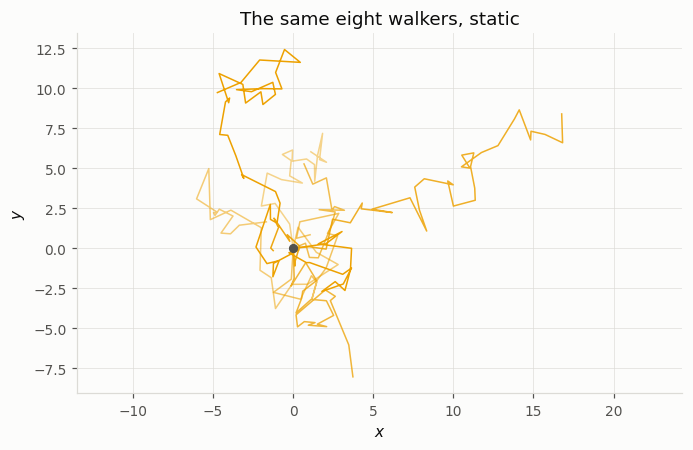

In [7]:
fig = plot_trajectories(walk, mechanism=few, n_show=8,
                        title="The same eight walkers, static")
fig

---

## Where this leaves the project

A single trajectory cannot separate CTRW from scaled Brownian motion from
normal diffusion, because two of the three report `α ≈ 1` regardless. That is a
wall in the information available to one observer, not a defect of the
estimator — which is exactly why `Q3` asks how many agents are needed and `Q4`
asks how they should be chosen.

`02_ensemble.ipynb` shows what the ensemble recovers, and measures how the
single-trajectory spread behaves as the observation lengthens.